## 5.2. Renewables focus (2023-2026)

In this part, the same regression analysis will be displayed, taking into consideration the period of time that goes from May 2023 to May 2026. 
Since the previous analylsis showed a structural decrease of prices with the increase of renewables production, that deviated from the typical linear rleationship between the two variables, it is appropriate to use updated information.  
This means that, instead of taking into consideration 2023-2025 dataset, 2023-2026 dataset shifted by 5 months is used for comparison and insights.

In [42]:
# import libraries
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# filter User and Filter Warnings for privacy matters
warnings.simplefilter(action='ignore', category=UserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

# define clean dataset folder path
clean_dataset_path = Path('../dataset/clean/updated')

# read merge-dataset
data = pd.read_csv(clean_dataset_path / 'merged-dataset.csv')

In [43]:
# filter dataset by date
data = data[
    (data['Date'] >= '2023-05-01 00:00:00')
    &
    (data['Date'] < '2026-06-01 00:00:00')
] 
data

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables weight,Total Load,Load forecasted
2878,2023-05-01 00:00:00,114.35000,0.63,2.50,0.00,2.448,8.63,1.42,13.18,0.345220,22409.25050,23168.75000
2879,2023-05-01 01:00:00,112.00000,0.63,2.40,0.00,2.318,7.49,1.41,11.93,0.372171,20911.74975,21754.50000
2880,2023-05-01 02:00:00,110.00000,0.63,2.35,0.00,2.209,7.09,1.43,11.50,0.383478,20022.24975,21118.00000
2881,2023-05-01 03:00:00,106.75000,0.63,2.37,0.00,2.147,6.85,1.52,11.37,0.397537,19595.00000,20621.75075
2882,2023-05-01 04:00:00,108.98000,0.63,2.40,0.00,2.138,6.82,1.61,11.46,0.404887,19424.00050,20515.00025
...,...,...,...,...,...,...,...,...,...,...,...,...
29867,2026-05-31 19:00:00,152.93646,0.60,6.98,1.44,2.244,12.71,2.31,24.04,0.471298,32567.75025,31232.99950
29868,2026-05-31 20:00:00,162.48019,0.60,8.46,0.11,1.864,13.14,2.09,24.40,0.461475,32957.50000,32526.00000
29869,2026-05-31 21:00:00,161.37194,0.60,8.78,0.00,1.784,13.40,1.93,24.71,0.457709,32685.74975,32675.74950
29870,2026-05-31 22:00:00,158.47406,0.60,7.13,0.00,1.600,13.72,1.87,23.32,0.411664,30581.49950,30908.00025


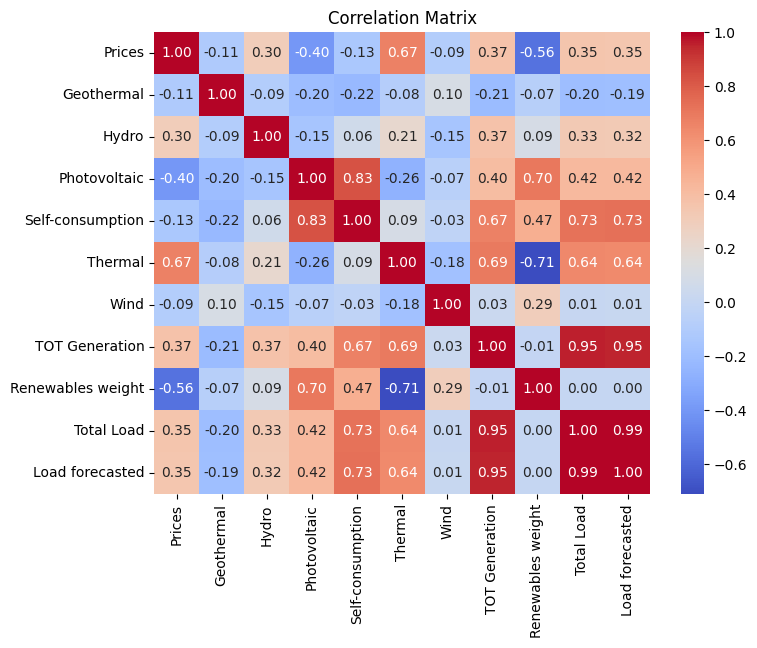

In [44]:
# correlation matrix
corr_matrix = data.corr(numeric_only=True)

# display heated matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

To further investigate the relationship about these two variable, a linear regression study is applied in order to find out more precisely how muche these variations happpen.

### Bivariate Linear Regression with OLS

In [45]:
data = data.rename(
    columns={'Renewables weight': 'Renewables_weight'}
)

data.head()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables_weight,Total Load,Load forecasted
2878,2023-05-01 00:00:00,114.35,0.63,2.50,0.0,2.448,8.63,1.42,13.18,0.345220,22409.25050,23168.75000
2879,2023-05-01 01:00:00,112.00,0.63,2.40,0.0,2.318,7.49,1.41,11.93,0.372171,20911.74975,21754.50000
2880,2023-05-01 02:00:00,110.00,0.63,2.35,0.0,2.209,7.09,1.43,11.50,0.383478,20022.24975,21118.00000
2881,2023-05-01 03:00:00,106.75,0.63,2.37,0.0,2.147,6.85,1.52,11.37,0.397537,19595.00000,20621.75075
2882,2023-05-01 04:00:00,108.98,0.63,2.40,0.0,2.138,6.82,1.61,11.46,0.404887,19424.00050,20515.00025


In [46]:
data.tail()

,Date,Prices,Geothermal,Hydro,Photovoltaic,Self-consumption,Thermal,Wind,TOT Generation,Renewables_weight,Total Load,Load forecasted
29867,2026-05-31 19:00:00,152.93646,0.6,6.98,1.44,2.244,12.71,2.31,24.04,0.471298,32567.75025,31232.99950
29868,2026-05-31 20:00:00,162.48019,0.6,8.46,0.11,1.864,13.14,2.09,24.40,0.461475,32957.50000,32526.00000
29869,2026-05-31 21:00:00,161.37194,0.6,8.78,0.00,1.784,13.40,1.93,24.71,0.457709,32685.74975,32675.74950
29870,2026-05-31 22:00:00,158.47406,0.6,7.13,0.00,1.600,13.72,1.87,23.32,0.411664,30581.49950,30908.00025
29871,2026-05-31 23:00:00,150.70448,0.6,6.08,0.00,1.388,13.30,1.97,21.95,0.394077,28210.50000,28413.50000


In [47]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

VAR_X = 'Renewables_weight'
VAR_Y = 'Prices'

formula = f'{VAR_Y} ~ {VAR_X}'

model = smf.ols(formula, data=data).fit()
print(f'\nLinear Regression Model - Prices and Renewables (2023 - 2026)\n')
print(model.summary())


Linear Regression Model - Prices and Renewables (2023 - 2026)

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                 1.226e+04
Date:                Mon, 29 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:05:16   Log-Likelihood:            -1.2557e+05
No. Observations:               26994   AIC:                         2.511e+05
Df Residuals:                   26992   BIC:                         2.512e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------

#### Visualizations

In [48]:
params = model.params

# x values
ax_x = 'Renewables_weight'
x = np.linspace(0, 1, 100)

# coefficients
b0 = model.params['Intercept']
b1 = model.params['Renewables_weight']

# f lines
y_d_0 = b0 + b1 * x 


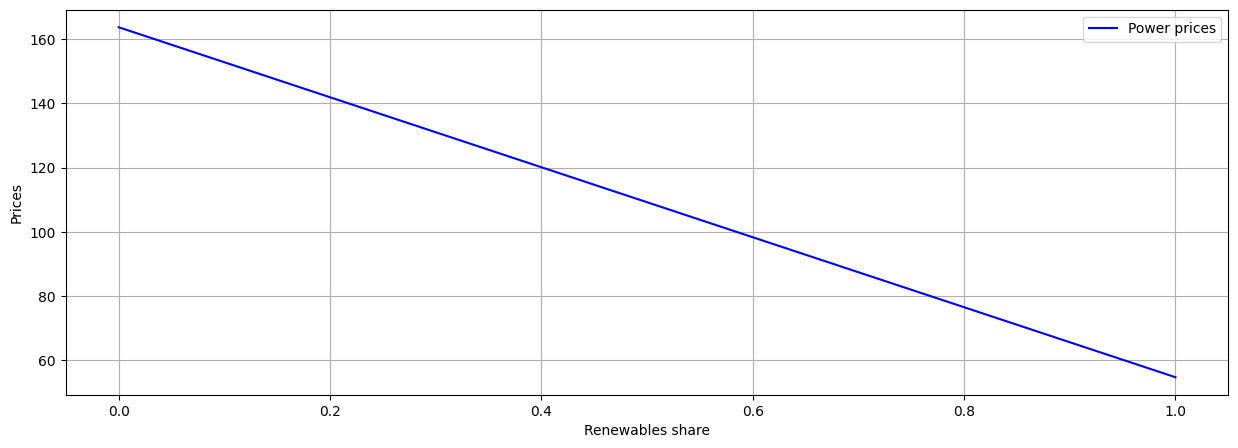

In [49]:
# matplotlib graph
plt.figure(figsize=(15, 5))
# plt.plot(x, y_d_1, color='sandybrown', label='D = 1 (no interaction)', )
plt.plot(x, y_d_0, color='blue', label='Power prices')
# plt.plot(x, y_interaction, color='red', label='D = 1 (interaction)')
plt.xlabel("Renewables share")
plt.ylabel("Prices")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
import plotly.express as px
import plotly.graph_objects as go 

fig = px.scatter(
    data, 
    x='Renewables_weight', 
    y='Prices', 
    hover_data={
        'Renewables_weight': True,
        'Prices': True, 
        'Date': True
    }, 
    opacity=0.05
)

fig.add_trace(
    go.Scatter(
        x=x,
        y=y_d_0,
        mode='lines',
        name='Power Prices',
        line=dict(width=4)
    )
)

fig.update_layout(
    title='Linear Regression (OLS)',
    xaxis_title='Renewables share',
    yaxis_title='Prices',
    template='simple_white'
)

fig.show()

In [51]:
# robust model to heteroskedasticity and autocorrelation
robust_model = smf.ols(
    formula,
    data=data
).fit(
    cov_type='HAC',
    cov_kwds={'maxlags':24}
)

print(f'\nRobust Linear Regression Model - Prices and Renewables (2023 - 2026)\n')
print(robust_model.summary())


Robust Linear Regression Model - Prices and Renewables (2023 - 2026)

                            OLS Regression Results                            
Dep. Variable:                 Prices   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     1477.
Date:                Mon, 29 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:05:17   Log-Likelihood:            -1.2557e+05
No. Observations:               26994   AIC:                         2.511e+05
Df Residuals:                   26992   BIC:                         2.512e+05
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------